# GARJI Prediction Model: Causal Network of Stock Volatilities
This notebook implements a predictive causality network among S&P 500 stocks using a GARCH-based volatility estimator with jump detection (as a proxy for GARJI), Granger causality tests, and network analysis/visualization.

In [1]:
# filter warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import requests
from io import StringIO
from arch import arch_model
from statsmodels.tsa.api import VAR
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from multiprocessing import Pool
from scipy.optimize import minimize



from statsmodels.tsa.api import VAR 
from statsmodels.stats.contrast import ContrastResults


## Configuration
Set the number of stocks, date range, lags for Granger causality, and significance level.

In [3]:
NUM_STOCKS = 100
START_DATE = '2023-06-01'
END_DATE = '2025-06-01'
LAGS = 5  # For Granger tests
ALPHA = 0.05  # Significance level

## Fetch S&P 500 Data
Download the list of S&P 100 components and their historical prices from Yahoo Finance.

In [4]:
# Get current S&P 500 components
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()
sp500 = pd.read_html(StringIO(response.text))[0]

tickers = sp500['Symbol'].tolist()[:NUM_STOCKS]
sector_map = dict(zip(sp500['Symbol'], sp500['GICS Sector']))

In [5]:
# remove 'BF.B' and 'BRK.B'
tickers = [ticker for ticker in tickers if ticker not in ['BF.B', 'BRK.B']]

In [6]:

# Download price data
data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=False)['Adj Close']
prices = data.dropna(axis=1)  # Remove stocks with missing data

[*********************100%***********************]  98 of 98 completed


## Calculate Log Returns

In [7]:
returns = np.log(prices / prices.shift(1)).dropna()

In [8]:
print(returns.head())

Ticker             A      AAPL      ABBV      ABNB       ABT      ACGL  \
Date                                                                     
2023-06-02  0.016718  0.004764  0.025380  0.051266  0.013332  0.017501   
2023-06-05  0.001099 -0.007600 -0.000073 -0.020279 -0.004232  0.005626   
2023-06-06 -0.007719 -0.002063 -0.010504  0.013821 -0.011048 -0.001404   
2023-06-07 -0.007264 -0.007787  0.007870 -0.006414 -0.009399  0.000702   
2023-06-08 -0.016431  0.015347  0.008317 -0.009050 -0.008694 -0.003656   

Ticker           ACN      ADBE       ADI       ADM  ...      CVNA      GOOG  \
Date                                                ...                       
2023-06-02  0.020079  0.022292  0.001391  0.019928  ... -0.007624  0.006891   
2023-06-05 -0.022539 -0.005031 -0.027173 -0.009774  ... -0.044336  0.011117   
2023-06-06  0.011723 -0.002975  0.016943  0.015593  ... -0.014775  0.010058   
2023-06-07  0.009660 -0.034237  0.013395  0.013310  ...  0.049499 -0.039630   
2023-06

## Estimate Volatilities (GARCH + Jump Detection as GARJI Proxy)

In [9]:
volatilities = pd.DataFrame(index=returns.index)
for ticker in tqdm(returns.columns, desc="Estimating Volatilities"):
    ret = returns[ticker]
    # GARCH(1,1) estimation
    model = arch_model(ret, p=1, q=1, dist='skewt')
    res = model.fit(disp='off')
    h = res.conditional_volatility
    # Jump detection (simplified)
    jumps = (np.abs(ret) > 3*ret.std()).astype(int)
    lambda_t = jumps.rolling(21).mean().fillna(0)  # 1-month rolling jump intensity
    # Combined volatility estimate (simplified Eq. 24)
    theta = ret.mean()  # Simplified jump size
    delta = ret.std()   # Simplified jump volatility
    sigma = np.sqrt(h**2 + lambda_t*(theta**2 + delta**2))
    volatilities[ticker] = sigma
volatilities = volatilities.dropna()

Estimating Volatilities:   0%|          | 0/98 [00:00<?, ?it/s]

Estimating Volatilities:   5%|▌         | 5/98 [00:00<00:09,  9.31it/s]c:\Users\massi\Documents\PythonAnalytics\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
Estimating Volatilities:   7%|▋         | 7/98 [00:00<00:09,  9.56it/s]c:\Users\massi\Documents\PythonAnalytics\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
Estimating Volatilities:   9%|▉         | 9/98 [00:01<00:08, 10.35it/s]c:\Users\massi\Documents\PythonAnalytics\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn

In [10]:
print(volatilities.head())

                   A      AAPL       ABBV      ABNB       ABT      ACGL  \
Date                                                                      
2023-06-02  0.014525  0.047009   0.006945  0.023712  0.010526  0.011439   
2023-06-05  0.015740  0.275870  13.053424  0.025248  0.010834  2.094555   
2023-06-06  0.016029  0.289026  12.673468  0.024859  0.010767  2.082683   
2023-06-07  0.016307  0.295498  12.610375  0.024346  0.010965  2.075654   
2023-06-08  0.016474  0.292282  12.363268  0.023816  0.011051  2.077759   

                 ACN       ADBE       ADI       ADM  ...      CVNA      GOOG  \
Date                                                 ...                       
2023-06-02  0.026851   0.072633  0.016946  0.042164  ...  0.133882  0.051002   
2023-06-05  0.035822  22.273359  0.016920  0.576647  ...  0.129410  0.213749   
2023-06-06  0.038790  21.665131  0.018271  0.559716  ...  0.125543  0.213037   
2023-06-07  0.041683  21.054417  0.018479  0.582289  ...  0.121433  0.2138

## Pairwise Granger Causality Tests
Test for predictive causality between all pairs of volatility series.

In [11]:

from scipy.stats import f

def build_VAR_design(vol_df, L):
    """
    vol_df: DataFrame (T x n)
    L: numero di lag
    Ritorna:
      X : (T-L, n*L)
      Y : (T-L, n)
    """
    vol = vol_df.values
    T, n = vol.shape
    T_eff = T - L

    # Y target
    Y = vol[L:, :]

    # X con tutti i lag concatenati
    X_lags = []
    for k in range(1, L+1):
        X_lags.append(vol[L-k:T-k, :])
    X = np.hstack(X_lags)

    return X, Y


In [12]:
from sklearn.linear_model import Ridge

def fit_VAR_ridge(X, Y, alpha=10.0):
    """
    X: (T_eff, n*L)
    Y: (T_eff, n)
    alpha: regolarizzazione Ridge
    Ritorna:
      B: coefficienti (n*L, n)
      intercept: (n,)
    """
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X, Y)
    B = model.coef_.T          # (n*L, n)
    intercept = model.intercept_
    return B, intercept


In [13]:
def wald_test_pair(B, i, j, n, L, X, Y):
    """
    B: (n*L, n) coefficienti Ridge
    i: target
    j: regressore
    n: numero serie
    L: lag
    X: design matrix (T_eff, n*L)
    Y: target matrix (T_eff, n)
    """
    # indici dei lag di j
    idx = []
    for k in range(L):
        idx.append(k*n + j)

    beta_j = B[idx, i]  # (L,)

    # residui modello pieno
    y = Y[:, i]
    y_hat_full = X @ B[:, i]
    SSR_full = np.sum((y - y_hat_full)**2)

    # modello ristretto: azzeriamo i coefficienti di j
    B_restr = B[:, i].copy()
    B_restr[idx] = 0.0
    y_hat_restr = X @ B_restr
    SSR_restr = np.sum((y - y_hat_restr)**2)

    # F-test
    df_num = L
    df_den = X.shape[0] - (n*L + 1)
    F_stat = ((SSR_restr - SSR_full) / df_num) / (SSR_full / df_den)
    pval = f.sf(F_stat, df_num, df_den)
    return pval


In [14]:
def granger_VAR_ridge(vol_df, L, alpha=10.0):
    X, Y = build_VAR_design(vol_df, L)
    T_eff, nL = X.shape
    n = Y.shape[1]

    B, intercept = fit_VAR_ridge(X, Y, alpha)

    pvals = np.ones((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            pvals[i, j] = wald_test_pair(B, i, j, n, L, X, Y)

    return pvals


In [15]:
LAGS = 5
ALPHA = 0.05

pvals = granger_VAR_ridge(volatilities, LAGS, alpha=10.0)

adj_matrix = (pvals < ALPHA).astype(int)
np.fill_diagonal(adj_matrix, 0)


## Build and Analyze the Causal Network

In [17]:
cols = volatilities.columns.tolist()

G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph())
for i, node in enumerate(G.nodes()):
    ticker = cols[i]
    G.nodes[node]['ticker'] = ticker
    G.nodes[node]['sector'] = sector_map.get(ticker, 'Unknown')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
top_influencers = sorted(
    [(G.nodes[n]['ticker'], out_degree[n]) for n in G.nodes()],
    key=lambda x: x[1], reverse=True
)[:10]
print("\nTop 10 Influential Stocks:")
for ticker, degree in top_influencers:
    print(f"{ticker} ({degree} connections)")

Nodes: 98
Edges: 10
Density: 0.0011

Top 10 Influential Stocks:
ADBE (1 connections)
AEP (1 connections)
AIG (1 connections)
ALB (1 connections)
ALLE (1 connections)
APD (1 connections)
BA (1 connections)
BX (1 connections)
CAT (1 connections)
SCHW (1 connections)


## Visualize the Causal Network

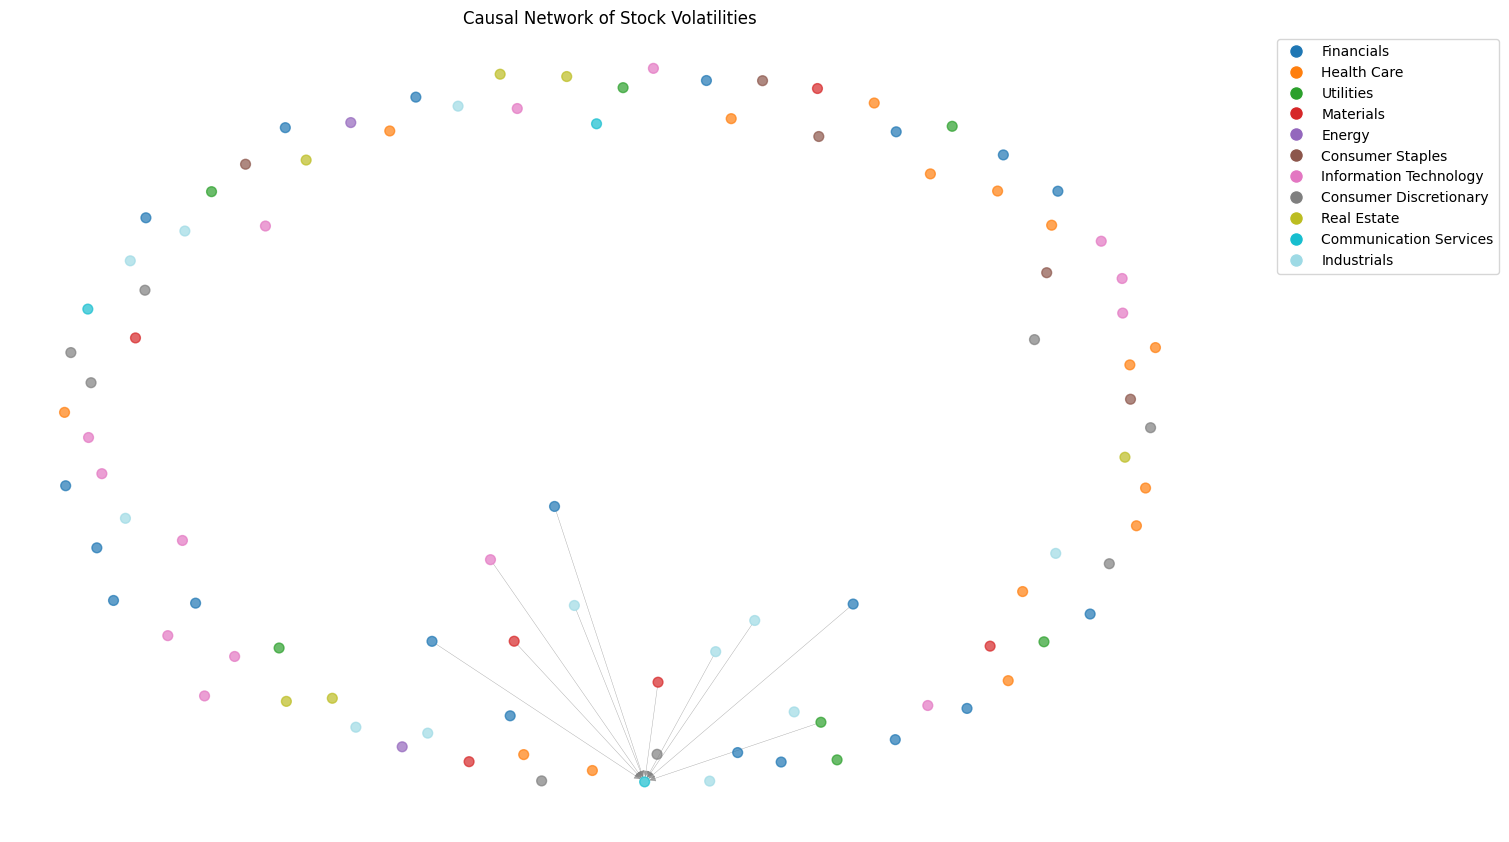

In [18]:
plt.figure(figsize=(12, 8))
sectors = set(nx.get_node_attributes(G, 'sector').values())
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
color_map = {sector: palette[i] for i, sector in enumerate(sectors)}
node_colors = [color_map[G.nodes[n]['sector']] for n in G.nodes()]
pos = nx.spring_layout(G, k=0.5)
nx.draw(
    G, pos,
    node_size=50,
    node_color=node_colors,
    alpha=0.7,
    with_labels=False,
    edge_color='gray',
    width=0.3
)
patches = [
    plt.Line2D([0], [0], marker='o', color='w', 
              markerfacecolor=color_map[s], markersize=10, label=s)
    for s in sectors
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Causal Network of Stock Volatilities")
plt.tight_layout()
plt.show()